In [ ]:
# # ACCESS-DP · USE CASE #3
# ## Long-Term Trajectory Failure
# ### Offline-first & secure escalation demo

# This notebook demonstrates:

# 1. Loading an extracted EHR rehab profile
# 2. Building a personalized rehabilitation plan
# 3. Generating expected milestone curves
# 4. Simulating daily home rehab logs
# 5. Detecting trajectory failure
# 6. Producing caregiver and clinician outputs
# 7. Creating a secure `share_record` payload

# Scenario:

# Patient: James Okafor  
# Age: 67 years old  
# Condition: Post-stroke rehabilitation, monitored entirely offline at home  
# Setting: Home-assisted by Diane, wife, non-clinical caregiver  
# Location: Rural Maryland, intermittent connectivity  
# Primary signal: Daily PT logging via app, no wearable  

from pathlib import Path
import json
import math
import textwrap
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional nicer display in notebooks
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# %%
INPUT_PROFILE_PATH = Path("./outputs/rehab_profile_extracted_v2.json")
OUTPUT_DIR = Path("access_dp_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Input profile:", INPUT_PROFILE_PATH)
print("Output folder:", OUTPUT_DIR.resolve())

Input profile: outputs\rehab_profile_extracted_v2.json
Output folder: C:\Users\jaymo\Desktop\Desktop\HTA_Internship\USE_CASE_3\uc3_ehr_demo\access_dp_outputs


In [ ]:
def make_json_serializable(obj):
    """
    Convert numpy/pandas objects into standard Python JSON-serializable objects.
    """
    if obj is None:
        return None

    if isinstance(obj, (str, int, float, bool)):
        if isinstance(obj, float) and (math.isnan(obj) or math.isinf(obj)):
            return None
        return obj

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        value = float(obj)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(obj, pd.Timestamp):
        if pd.isna(obj):
            return None
        return obj.isoformat()

    if obj is pd.NaT:
        return None

    if isinstance(obj, dict):
        return {
            str(make_json_serializable(k)): make_json_serializable(v)
            for k, v in obj.items()
        }

    if isinstance(obj, list):
        return [make_json_serializable(x) for x in obj]

    if isinstance(obj, tuple):
        return [make_json_serializable(x) for x in obj]

    if isinstance(obj, set):
        return [make_json_serializable(x) for x in sorted(obj)]

    return str(obj)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    clean_obj = make_json_serializable(obj)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(clean_obj, f, indent=2, ensure_ascii=False)
    print(f"Saved JSON: {path}")

def save_text(text, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)
    print(f"Saved text: {path}")

def load_ehr_payload(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [5]:
# %% [markdown]
# ## 2. Load Extracted EHR Rehab Profile

# %%
ehr_payload = load_ehr_payload(INPUT_PROFILE_PATH)

print("Top-level keys:")
print(list(ehr_payload.keys()))

preview_keys = [
    "patient",
    "condition_group",
    "rehab_flags",
    "mobility_context",
    "musculoskeletal_context",
    "neurologic_context",
    "medication_context",
    "encounter_timeline",
]

for key in preview_keys:
    if key in ehr_payload:
        print(f"\n--- {key} ---")
        value = ehr_payload[key]
        if isinstance(value, dict):
            print(json.dumps(value, indent=2)[:1000])
        elif isinstance(value, list):
            print(f"List length: {len(value)}")
            print(json.dumps(value[:3], indent=2)[:1000])
        else:
            print(value)

Top-level keys:
['ehr_profile_version', 'source_files', 'encounter_timeline', 'merged_profile', 'ml_patient_profile', 'file_level_profiles']

--- encounter_timeline ---
List length: 93
[
  {
    "source_file": "DOC0095_deidentified_timeline.json",
    "visit_index": 1,
    "days_from_first_visit": 0,
    "days_since_previous_visit": null,
    "visit_label": null,
    "section_titles": [
      "Active Problems",
      "Advance Directives",
      "Allergies",
      "Discharge Instructions",
      "Last Filed Vital Signs",
      "Medications",
      "Note from Organization Redacted",
      "Plan of Treatment",
      "Procedures",
      "Results",
      "Social History",
      "Summary of Care",
      "[REDACTED] Details"
    ],
    "mobility_related": true,
    "musculoskeletal_related": true,
    "tone_spasticity_related": true,
    "pain_related": true,
    "equipment_related": true,
    "procedure_related": true,
    "deconditioning_related": false
  },
  {
    "source_file": "DOC0094_

In [7]:
# %% [markdown]
# ## 3. EHR Relative Timeline
#
# Exact dates are redacted, so this demo uses relative chronology:
#
# - `visit_index`
# - `days_from_first_visit`
# - `days_since_previous_visit`
#
# The latest EHR visit becomes the home rehab monitoring anchor.

# %%
def build_ehr_timeline_df(ehr_payload):
    timeline = ehr_payload.get("encounter_timeline", [])

    if not timeline:
        return pd.DataFrame(
            columns=[
                "visit_index",
                "days_from_first_visit",
                "days_since_previous_visit",
                "source_file",
                "encounter_type",
                "section_count",
            ]
        )

    rows = []
    for i, item in enumerate(timeline):
        rows.append(
            {
                "visit_index": item.get("visit_index", item.get("index", i)),
                "days_from_first_visit": item.get("days_from_first_visit"),
                "days_since_previous_visit": item.get("days_since_previous_visit"),
                "source_file": item.get("source_file", item.get("filename", "")),
                "encounter_type": item.get("encounter_type", item.get("type", "EHR encounter")),
                "section_count": item.get("section_count", item.get("entry_count", None)),
            }
        )

    df = pd.DataFrame(rows)

    if "days_from_first_visit" in df.columns:
        df["days_from_first_visit"] = pd.to_numeric(df["days_from_first_visit"], errors="coerce")

    if "visit_index" in df.columns:
        df["visit_index"] = pd.to_numeric(df["visit_index"], errors="coerce")

    df = df.sort_values(
        by=["days_from_first_visit", "visit_index"],
        na_position="last"
    ).reset_index(drop=True)

    return df

ehr_timeline_df = build_ehr_timeline_df(ehr_payload)

display(ehr_timeline_df.head(20))
print("Timeline rows:", len(ehr_timeline_df))

,visit_index,days_from_first_visit,days_since_previous_visit,source_file,encounter_type,section_count
0,1,0,NaN,DOC0095_deidentified_timeline.json,EHR encounter,None
1,2,87,87.0,DOC0094_deidentified_timeline.json,EHR encounter,None
2,3,1372,1285.0,DOC0008_deidentified_timeline.json,EHR encounter,None
3,4,1372,0.0,DOC0021_deidentified_timeline.json,EHR encounter,None
4,5,2519,1146.0,DOC0093_deidentified_timeline.json,EHR encounter,None
5,6,2522,2.0,DOC0091_deidentified_timeline.json,EHR encounter,None
6,7,2522,0.0,DOC0090_deidentified_timeline.json,EHR encounter,None
7,8,2527,5.0,DOC0092_deidentified_timeline.json,EHR encounter,None
8,9,2568,40.0,DOC0089_deidentified_timeline.json,EHR encounter,None
9,10,2666,98.0,DOC0088_deidentified_timeline.json,EHR encounter,None


Timeline rows: 93


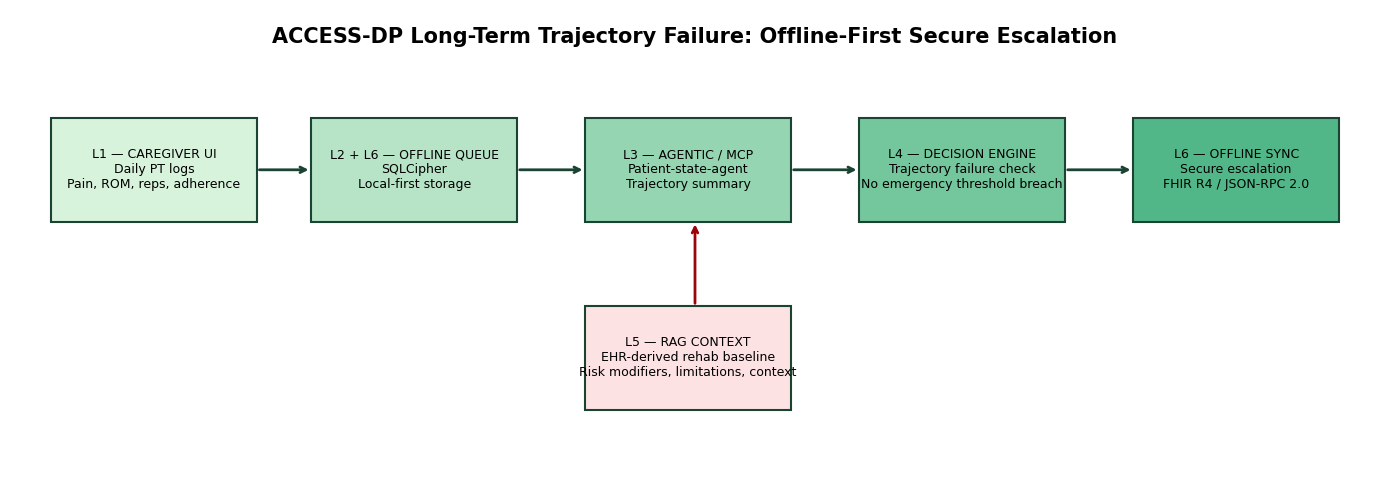

In [9]:
# %% [markdown]
# ## 5. Visual: ACCESS-DP Pipeline Diagram

# %%
def draw_access_dp_pipeline():
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")

    boxes = [
        {
            "label": "L1 — CAREGIVER UI\nDaily PT logs\nPain, ROM, reps, adherence",
            "xy": (0.03, 0.55),
            "color": "#D8F3DC",
        },
        {
            "label": "L2 + L6 — OFFLINE QUEUE\nSQLCipher\nLocal-first storage",
            "xy": (0.22, 0.55),
            "color": "#B7E4C7",
        },
        {
            "label": "L3 — AGENTIC / MCP\nPatient-state-agent\nTrajectory summary",
            "xy": (0.42, 0.55),
            "color": "#95D5B2",
        },
        {
            "label": "L4 — DECISION ENGINE\nTrajectory failure check\nNo emergency threshold breach",
            "xy": (0.62, 0.55),
            "color": "#74C69D",
        },
        {
            "label": "L6 — OFFLINE SYNC\nSecure escalation\nFHIR R4 / JSON-RPC 2.0",
            "xy": (0.82, 0.55),
            "color": "#52B788",
        },
        {
            "label": "L5 — RAG CONTEXT\nEHR-derived rehab baseline\nRisk modifiers, limitations, context",
            "xy": (0.42, 0.15),
            "color": "#FDE2E4",
        },
    ]

    box_w = 0.15
    box_h = 0.22

    for box in boxes:
        x, y = box["xy"]
        rect = plt.Rectangle(
            (x, y),
            box_w,
            box_h,
            facecolor=box["color"],
            edgecolor="#1B4332",
            linewidth=1.5
        )
        ax.add_patch(rect)
        ax.text(
            x + box_w / 2,
            y + box_h / 2,
            box["label"],
            ha="center",
            va="center",
            fontsize=9,
            wrap=True
        )

    # horizontal arrows
    arrow_pairs = [
        ((0.18, 0.66), (0.22, 0.66)),
        ((0.37, 0.66), (0.42, 0.66)),
        ((0.57, 0.66), (0.62, 0.66)),
        ((0.77, 0.66), (0.82, 0.66)),
    ]

    for start, end in arrow_pairs:
        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle="->", linewidth=2, color="#1B4332")
        )

    # RAG context arrow upward
    ax.annotate(
        "",
        xy=(0.50, 0.55),
        xytext=(0.50, 0.37),
        arrowprops=dict(arrowstyle="->", linewidth=2, color="#9D0208")
    )

    ax.text(
        0.5,
        0.93,
        "ACCESS-DP Long-Term Trajectory Failure: Offline-First Secure Escalation",
        ha="center",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

draw_access_dp_pipeline()

In [11]:
# %% [markdown]
# ## 6. Rehab Personalization Functions
#
# The personalized plan is intentionally transparent and rule-based for demo/MVP purposes.
#
# EHR contributes:
#
# - complexity score
# - risk modifiers
# - relevant metrics
# - milestone adjustment
# - clinician review context
#
# Daily app logs remain the primary trajectory signal.

# %%
def get_nested(payload, *keys, default=None):
    current = payload
    for key in keys:
        if not isinstance(current, dict):
            return default
        current = current.get(key)
        if current is None:
            return default
    return current

def flatten_text_values(obj):
    values = []

    if obj is None:
        return values

    if isinstance(obj, str):
        values.append(obj.lower())

    elif isinstance(obj, dict):
        for v in obj.values():
            values.extend(flatten_text_values(v))

    elif isinstance(obj, list):
        for item in obj:
            values.extend(flatten_text_values(item))

    return values

def payload_contains(ehr_payload, keywords):
    text_blob = " ".join(flatten_text_values(ehr_payload))
    return any(keyword.lower() in text_blob for keyword in keywords)

def calculate_rehab_complexity_score(ehr_payload):
    """
    Transparent demo scoring.
    Higher score = more complex rehab context.
    """

    factors = []

    def add(condition, points, label):
        if condition:
            factors.append({"factor": label, "points": points})

    add(
        payload_contains(ehr_payload, ["stroke", "cva", "hemiparesis", "hemiplegia"]),
        2,
        "Neurologic motor recovery context"
    )

    add(
        payload_contains(ehr_payload, ["spasticity", "spastic", "baclofen", "diazepam", "botox"]),
        2,
        "Tone/spasticity management context"
    )

    add(
        payload_contains(ehr_payload, ["contracture", "limited rom", "range of motion"]),
        2,
        "Contracture or ROM limitation"
    )

    add(
        payload_contains(ehr_payload, ["hip dislocation", "subluxation", "dysplasia", "scoliosis"]),
        2,
        "Musculoskeletal structural limitation"
    )

    add(
        payload_contains(ehr_payload, ["wheelchair", "afo", "stander", "assistive device"]),
        1,
        "Assistive device or mobility equipment"
    )

    add(
        payload_contains(ehr_payload, ["pain", "chronic pain"]),
        1,
        "Pain-relevant rehab context"
    )

    add(
        payload_contains(ehr_payload, ["dvt", "deep vein thrombosis"]),
        1,
        "Vascular risk history"
    )

    add(
        payload_contains(ehr_payload, ["icu", "deconditioning", "hospitalization"]),
        1,
        "Deconditioning or hospitalization context"
    )

    raw_score = sum(f["points"] for f in factors)
    normalized = min(10, raw_score)

    return {
        "score": normalized,
        "raw_score": raw_score,
        "factors": factors
    }

def get_metric_relevance(ehr_payload, complexity_score):
    """
    Determine which rehab metrics matter most.
    Scores are demo weights from 0 to 1.
    """

    relevance = {
        "rom_degrees": 0.90,
        "exercise_reps": 0.75,
        "adherence": 0.80,
        "pain_score": 0.70,
        "fatigue_score": 0.55,
        "walking_minutes": 0.65,
    }

    if payload_contains(ehr_payload, ["contracture", "limited rom", "range of motion"]):
        relevance["rom_degrees"] += 0.08

    if payload_contains(ehr_payload, ["pain", "chronic pain"]):
        relevance["pain_score"] += 0.12

    if payload_contains(ehr_payload, ["wheelchair", "afo", "stander"]):
        relevance["walking_minutes"] -= 0.15
        relevance["exercise_reps"] += 0.05

    if payload_contains(ehr_payload, ["spasticity", "spastic", "baclofen", "diazepam", "botox"]):
        relevance["rom_degrees"] += 0.05
        relevance["fatigue_score"] += 0.05

    # Complexity makes safety/pain/fatigue more important
    if complexity_score >= 6:
        relevance["pain_score"] += 0.05
        relevance["fatigue_score"] += 0.05

    return {
        metric: round(float(min(1.0, max(0.0, value))), 3)
        for metric, value in relevance.items()
    }

def generate_milestone_curve(start, target, days, complexity_score, metric_name):
    """
    Generate an expected trajectory curve.

    Higher complexity slows the expected improvement rate.
    """

    x = np.arange(days)

    complexity_slowdown = 1.0 - min(complexity_score, 10) * 0.035
    complexity_slowdown = max(0.55, complexity_slowdown)

    # Different metrics improve differently
    if metric_name in ["rom_degrees", "walking_minutes"]:
        curve_shape = 1 - np.exp(-x / (days * 0.45 / complexity_slowdown))
    elif metric_name in ["exercise_reps", "adherence"]:
        curve_shape = 1 - np.exp(-x / (days * 0.35 / complexity_slowdown))
    else:
        curve_shape = np.linspace(0, 1, days)

    curve_shape = curve_shape / curve_shape[-1]

    values = start + (target - start) * curve_shape

    return [round(float(v), 2) for v in values]

def infer_condition_group(ehr_payload):
    if "condition_group" in ehr_payload and ehr_payload["condition_group"]:
        return ehr_payload["condition_group"]

    if payload_contains(ehr_payload, ["stroke", "cva", "hemiparesis", "hemiplegia"]):
        return "post_stroke_rehabilitation"

    if payload_contains(ehr_payload, ["cerebral palsy", "spastic quadriplegic"]):
        return "complex_neuromotor_rehabilitation"

    return "general_home_rehabilitation"

def generate_personalized_plan(ehr_payload, duration_days=21):
    complexity = calculate_rehab_complexity_score(ehr_payload)
    complexity_score = complexity["score"]
    metric_relevance = get_metric_relevance(ehr_payload, complexity_score)

    condition_group = infer_condition_group(ehr_payload)

    # Demo baseline values
    baseline_values = {
        "rom_degrees": 42,
        "exercise_reps": 8,
        "adherence": 0.86,
        "pain_score": 3.2,
        "fatigue_score": 4.0,
        "walking_minutes": 5,
    }

    # Generic clinical targets before personalization
    generic_targets = {
        "rom_degrees": 72,
        "exercise_reps": 22,
        "adherence": 0.90,
        "pain_score": 2.0,
        "fatigue_score": 3.0,
        "walking_minutes": 15,
    }

    # Adjust target aggressiveness based on complexity
    target_values = {}

    for metric, baseline in baseline_values.items():
        target = generic_targets[metric]

        if metric in ["rom_degrees", "exercise_reps", "walking_minutes"]:
            gain = target - baseline
            adjusted_gain = gain * (1.0 - min(complexity_score, 10) * 0.025)
            target_values[metric] = round(float(baseline + adjusted_gain), 2)

        elif metric in ["pain_score", "fatigue_score"]:
            improvement = baseline - target
            adjusted_improvement = improvement * (1.0 - min(complexity_score, 10) * 0.02)
            target_values[metric] = round(float(baseline - adjusted_improvement), 2)

        else:
            target_values[metric] = target

    milestones = {}
    for metric in baseline_values:
        milestones[metric] = generate_milestone_curve(
            start=baseline_values[metric],
            target=target_values[metric],
            days=duration_days,
            complexity_score=complexity_score,
            metric_name=metric,
        )

    plan = {
        "plan_id": "ACCESS-DP-REHAB-PLAN-DEMO-001",
        "scenario": "ACCESS-DP · USE CASE #3: LONG-TERM TRAJECTORY FAILURE",
        "patient": {
            "name": "James Okafor",
            "age": "67 years old",
            "condition": "Post-stroke rehabilitation, monitored entirely offline at home",
            "caregiver": "Diane, wife, non-clinical",
            "location": "Rural Maryland, intermittent connectivity",
        },
        "condition_group": condition_group,
        "duration_days": duration_days,
        "complexity_score": complexity_score,
        "complexity_breakdown": complexity,
        "metric_relevance": metric_relevance,
        "baseline_values": baseline_values,
        "target_values": target_values,
        "milestones": milestones,
        "clinician_authored_goals": [
            "Continue daily home PT program.",
            "Improve functional range of motion over 3 weeks.",
            "Maintain adherence without increasing pain or fatigue.",
            "Escalate non-emergently if progress plateaus despite adherence.",
        ],
        "safety_boundaries": {
            "emergency_thresholds": [
                "new severe neurologic symptoms",
                "chest pain",
                "shortness of breath",
                "fall with injury",
                "sudden severe pain"
            ],
            "non_emergency_escalation": [
                "sustained trajectory failure",
                "9-day plateau",
                "ROM 35% below week-3 milestone",
                "caregiver uncertainty despite adherence"
            ]
        }
    }

    return plan

personalized_plan = generate_personalized_plan(ehr_payload, duration_days=21)

print(json.dumps(personalized_plan, indent=2)[:2500])

{
  "plan_id": "ACCESS-DP-REHAB-PLAN-DEMO-001",
  "scenario": "ACCESS-DP \u00b7 USE CASE #3: LONG-TERM TRAJECTORY FAILURE",
  "patient": {
    "name": "James Okafor",
    "age": "67 years old",
    "condition": "Post-stroke rehabilitation, monitored entirely offline at home",
    "caregiver": "Diane, wife, non-clinical",
    "location": "Rural Maryland, intermittent connectivity"
  },
  "condition_group": "post_stroke_rehabilitation",
  "duration_days": 21,
  "complexity_score": 10,
  "complexity_breakdown": {
    "score": 10,
    "raw_score": 12,
    "factors": [
      {
        "factor": "Neurologic motor recovery context",
        "points": 2
      },
      {
        "factor": "Tone/spasticity management context",
        "points": 2
      },
      {
        "factor": "Contracture or ROM limitation",
        "points": 2
      },
      {
        "factor": "Musculoskeletal structural limitation",
        "points": 2
      },
      {
        "factor": "Assistive device or mobility equi

,factor,points
0,Neurologic motor recovery context,2
1,Tone/spasticity management context,2
2,Contracture or ROM limitation,2
3,Musculoskeletal structural limitation,2
4,Assistive device or mobility equipment,1
5,Pain-relevant rehab context,1
6,Vascular risk history,1
7,Deconditioning or hospitalization context,1


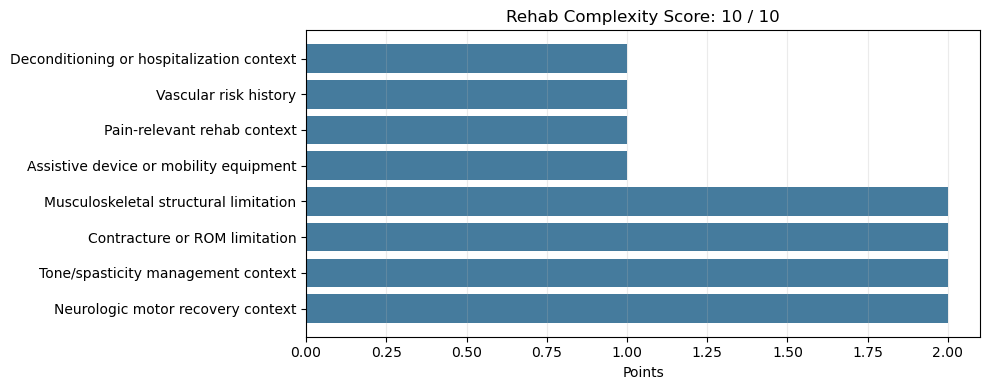

In [15]:
# %% [markdown]
# ## 7. Visual: Complexity Score Breakdown

# %%
complexity_df = pd.DataFrame(personalized_plan["complexity_breakdown"]["factors"])

if complexity_df.empty:
    print("No complexity factors detected.")
else:
    display(complexity_df)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(
        complexity_df["factor"],
        complexity_df["points"],
        color="#457B9D"
    )
    ax.set_title(
        f"Rehab Complexity Score: {personalized_plan['complexity_score']} / 10"
    )
    ax.set_xlabel("Points")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

,metric,relevance
5,walking_minutes,0.50
4,fatigue_score,0.65
1,exercise_reps,0.80
2,adherence,0.80
3,pain_score,0.87
0,rom_degrees,1.00


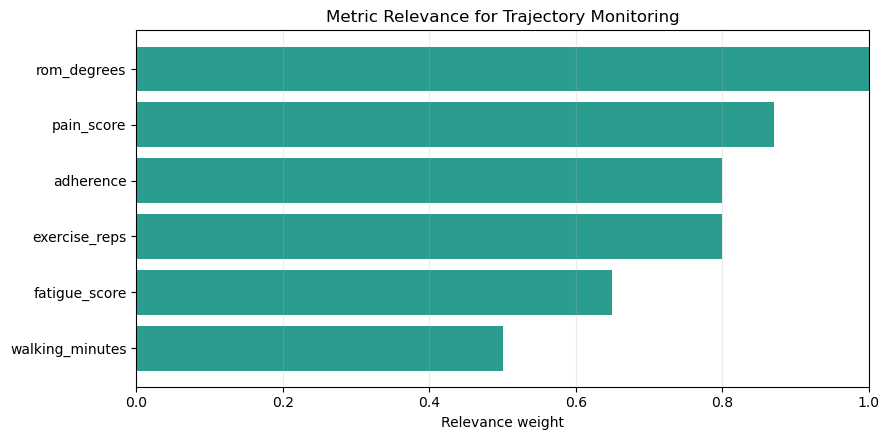

In [17]:
# %% [markdown]
# ## 8. Visual: Metric Relevance

# %%
metric_relevance_df = (
    pd.DataFrame(
        list(personalized_plan["metric_relevance"].items()),
        columns=["metric", "relevance"]
    )
    .sort_values("relevance", ascending=True)
)

display(metric_relevance_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    metric_relevance_df["metric"],
    metric_relevance_df["relevance"],
    color="#2A9D8F"
)
ax.set_xlim(0, 1)
ax.set_title("Metric Relevance for Trajectory Monitoring")
ax.set_xlabel("Relevance weight")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

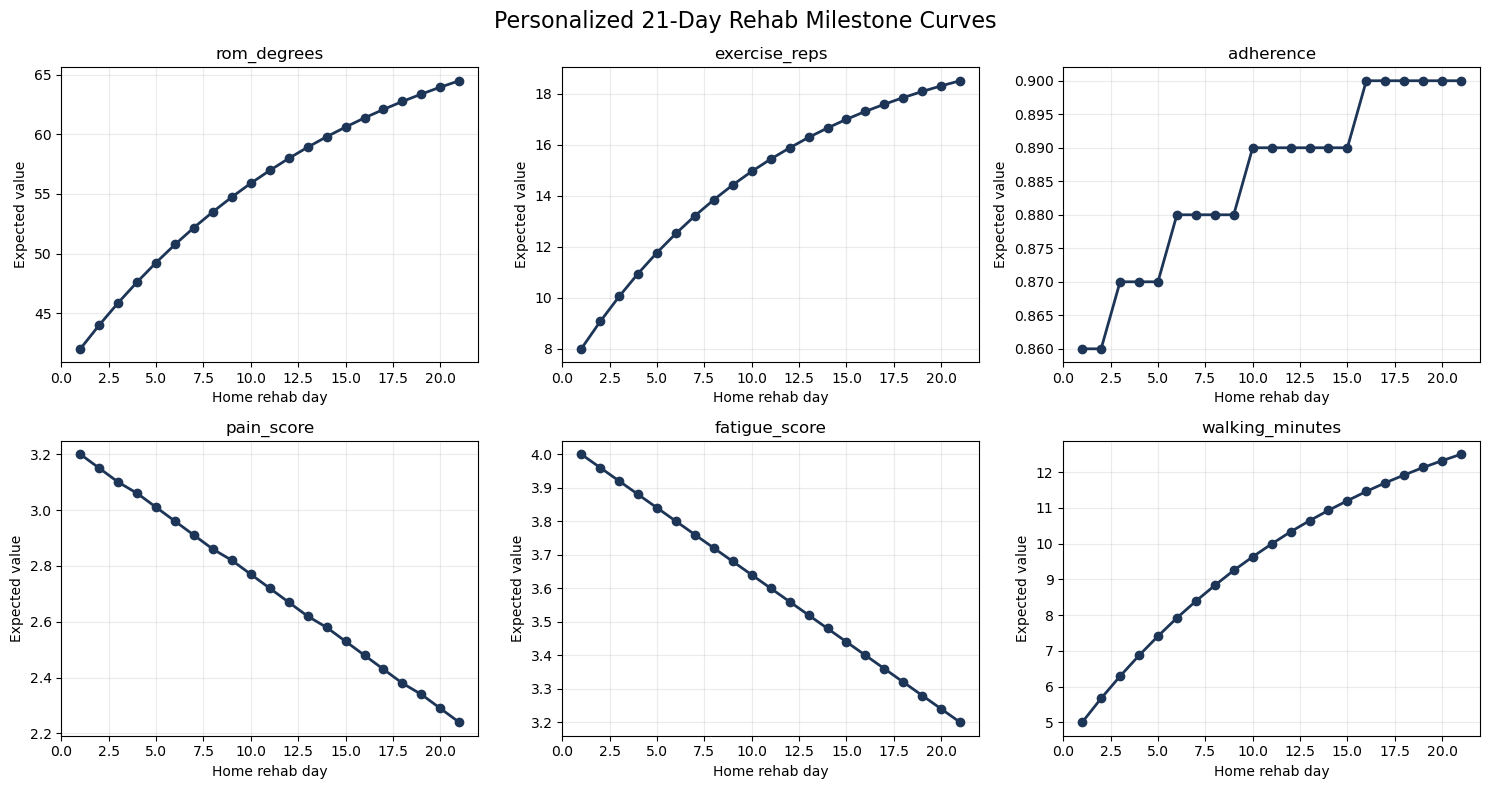

In [19]:
# %% [markdown]
# ## 9. Visual: Personalized Milestone Curves
#
# These curves represent the **expected trajectory**, not the actual patient data.

# %%
def plot_milestone_curves(plan):
    milestones = plan["milestones"]
    days = np.arange(1, plan["duration_days"] + 1)

    metrics = list(milestones.keys())
    n = len(metrics)

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        ax.plot(
            days,
            milestones[metric],
            marker="o",
            linewidth=2,
            color="#1D3557"
        )
        ax.set_title(metric)
        ax.set_xlabel("Home rehab day")
        ax.set_ylabel("Expected value")
        ax.grid(alpha=0.25)

    for ax in axes[len(metrics):]:
        ax.axis("off")

    fig.suptitle("Personalized 21-Day Rehab Milestone Curves", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_milestone_curves(personalized_plan)

In [21]:
# %% [markdown]
# ## 10. Determine Home Rehab Monitoring Anchor

# %%
def get_rehab_monitoring_anchor(ehr_payload, ehr_timeline_df):
    if not ehr_timeline_df.empty and "days_from_first_visit" in ehr_timeline_df.columns:
        valid_days = ehr_timeline_df["days_from_first_visit"].dropna()
        if not valid_days.empty:
            latest_ehr_day = int(valid_days.max())
        else:
            latest_ehr_day = 0
    else:
        latest_ehr_day = 0

    return {
        "anchor_type": "latest_available_ehr_visit",
        "latest_ehr_relative_day": latest_ehr_day,
        "home_rehab_day_0": latest_ehr_day,
        "home_rehab_relative_axis": "ehr_relative_day = latest_ehr_relative_day + home_rehab_day"
    }

rehab_anchor = get_rehab_monitoring_anchor(ehr_payload, ehr_timeline_df)

print(json.dumps(rehab_anchor, indent=2))

{
  "anchor_type": "latest_available_ehr_visit",
  "latest_ehr_relative_day": 6198,
  "home_rehab_day_0": 6198,
  "home_rehab_relative_axis": "ehr_relative_day = latest_ehr_relative_day + home_rehab_day"
}


In [23]:
# %% [markdown]
# ## 11. Generate Synthetic Daily Home Rehab Data
#
# This simulates the home app logs.
#
# Important:
#
# - The patient is adherent.
# - The patient is doing exercises daily.
# - But ROM improvement plateaus.
# - This creates long-term trajectory failure without an emergency threshold breach.

# %%
def synthetic_daily_rehab_data(plan, rehab_anchor, seed=42):
    rng = np.random.default_rng(seed)
    days = np.arange(1, plan["duration_days"] + 1)

    expected_rom = np.array(plan["milestones"]["rom_degrees"])
    expected_reps = np.array(plan["milestones"]["exercise_reps"])
    expected_adherence = np.array(plan["milestones"]["adherence"])
    expected_pain = np.array(plan["milestones"]["pain_score"])
    expected_fatigue = np.array(plan["milestones"]["fatigue_score"])
    expected_walking = np.array(plan["milestones"]["walking_minutes"])

    rows = []

    for i, day in enumerate(days):
        # Adherence remains high
        adherence = float(np.clip(rng.normal(0.91, 0.035), 0.78, 1.0))

        # ROM improves early, then plateaus around day 12
        if day <= 8:
            rom = 42 + day * 1.1 + rng.normal(0, 0.8)
        elif day <= 12:
            rom = 51 + rng.normal(0, 0.7)
        else:
            rom = 52 + rng.normal(0, 0.6)

        # Reps improve modestly
        reps = min(18, 8 + day * 0.45 + rng.normal(0, 1.0))

        # Pain does not spike
        pain = float(np.clip(rng.normal(3.0, 0.45), 1.5, 5.0))

        # Fatigue mildly elevated
        fatigue = float(np.clip(rng.normal(4.2, 0.55), 2.5, 6.5))

        # Walking minutes improve only mildly
        walking = min(10, 5 + day * 0.18 + rng.normal(0, 0.7))

        latest_ehr_day = rehab_anchor["latest_ehr_relative_day"]
        ehr_relative_day = latest_ehr_day + int(day)

        rows.append(
            {
                "home_rehab_day": int(day),
                "ehr_relative_day": int(ehr_relative_day),

                "rom_degrees_actual": round(float(rom), 2),
                "rom_degrees_expected": round(float(expected_rom[i]), 2),

                "exercise_reps_actual": round(float(reps), 2),
                "exercise_reps_expected": round(float(expected_reps[i]), 2),

                "adherence_actual": round(float(adherence), 3),
                "adherence_expected": round(float(expected_adherence[i]), 3),

                "pain_score_actual": round(float(pain), 2),
                "pain_score_expected": round(float(expected_pain[i]), 2),

                "fatigue_score_actual": round(float(fatigue), 2),
                "fatigue_score_expected": round(float(expected_fatigue[i]), 2),

                "walking_minutes_actual": round(float(walking), 2),
                "walking_minutes_expected": round(float(expected_walking[i]), 2),
            }
        )

    return pd.DataFrame(rows)

daily_df = synthetic_daily_rehab_data(personalized_plan, rehab_anchor, seed=RANDOM_SEED)

display(daily_df.head())
display(daily_df.tail())

,home_rehab_day,ehr_relative_day,rom_degrees_actual,rom_degrees_expected,exercise_reps_actual,exercise_reps_expected,adherence_actual,adherence_expected,pain_score_actual,pain_score_expected,fatigue_score_actual,fatigue_score_expected,walking_minutes_actual,walking_minutes_expected
0,1,6199,42.27,42.00,9.20,8.00,0.921,0.86,3.42,3.20,3.13,4.00,4.27,5.00
1,2,6200,43.95,44.00,8.88,9.07,0.914,0.86,2.62,3.15,4.68,3.96,5.90,5.67
2,3,6201,46.20,45.87,9.82,10.05,0.912,0.87,2.61,3.10,4.40,3.92,4.87,6.29
3,4,6202,46.36,47.61,9.62,10.95,0.941,0.87,2.69,3.06,4.87,3.88,5.61,6.87
4,5,6203,47.22,49.24,10.78,11.77,0.895,0.87,3.16,3.01,4.43,3.84,6.20,7.41


,home_rehab_day,ehr_relative_day,rom_degrees_actual,rom_degrees_expected,exercise_reps_actual,exercise_reps_expected,adherence_actual,adherence_expected,pain_score_actual,pain_score_expected,fatigue_score_actual,fatigue_score_expected,walking_minutes_actual,walking_minutes_expected
16,17,6215,51.40,62.09,16.05,17.58,0.864,0.9,2.59,2.43,3.99,3.36,8.97,11.70
17,18,6216,52.44,62.76,15.17,17.84,0.898,0.9,2.91,2.38,3.68,3.32,8.00,11.92
18,19,6217,50.96,63.38,16.98,18.08,0.939,0.9,3.11,2.34,3.87,3.28,7.41,12.13
19,20,6218,51.68,63.96,17.23,18.30,0.913,0.9,3.01,2.29,5.08,3.24,8.43,12.32
20,21,6219,52.11,64.50,17.67,18.50,0.874,0.9,3.61,2.24,4.66,3.20,9.03,12.50


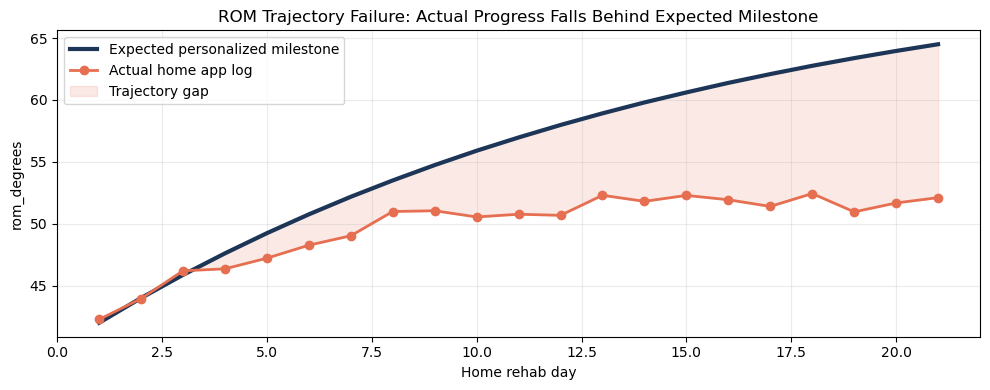

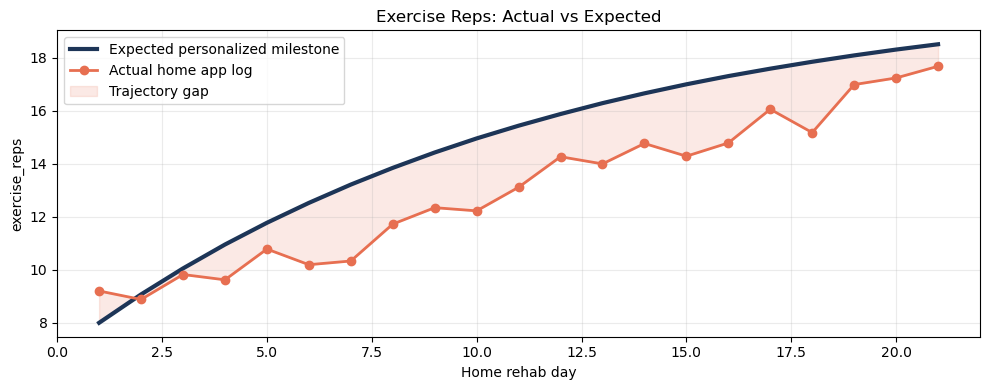

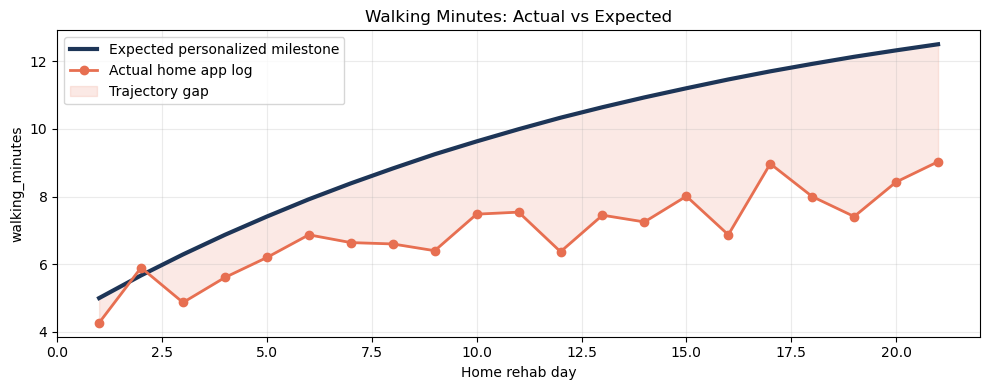

In [25]:
# %% [markdown]
# ## 12. Visual: Actual vs Expected Rehab Trajectories

# %%
def plot_actual_vs_expected(df, metric, title=None):
    actual_col = f"{metric}_actual"
    expected_col = f"{metric}_expected"

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        df["home_rehab_day"],
        df[expected_col],
        label="Expected personalized milestone",
        linewidth=3,
        color="#1D3557"
    )

    ax.plot(
        df["home_rehab_day"],
        df[actual_col],
        label="Actual home app log",
        marker="o",
        linewidth=2,
        color="#E76F51"
    )

    ax.fill_between(
        df["home_rehab_day"],
        df[actual_col],
        df[expected_col],
        color="#E76F51",
        alpha=0.15,
        label="Trajectory gap"
    )

    ax.set_title(title or f"{metric}: Actual vs Expected")
    ax.set_xlabel("Home rehab day")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_actual_vs_expected(
    daily_df,
    "rom_degrees",
    "ROM Trajectory Failure: Actual Progress Falls Behind Expected Milestone"
)

plot_actual_vs_expected(
    daily_df,
    "exercise_reps",
    "Exercise Reps: Actual vs Expected"
)

plot_actual_vs_expected(
    daily_df,
    "walking_minutes",
    "Walking Minutes: Actual vs Expected"
)

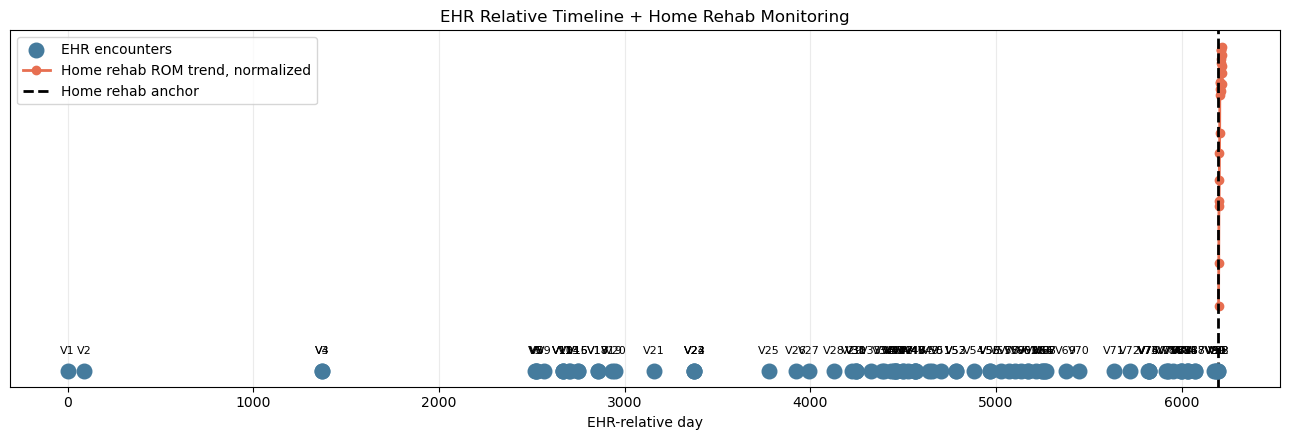

In [27]:
# %% [markdown]
# ## 13. Visual: EHR-Relative Axis
#
# This connects pre-home-rehab EHR context to daily home monitoring.

# %%
def plot_ehr_plus_home_rehab(ehr_df, daily_df):
    fig, ax = plt.subplots(figsize=(13, 4.5))

    if not ehr_df.empty and not ehr_df["days_from_first_visit"].isna().all():
        ehr_plot = ehr_df.dropna(subset=["days_from_first_visit"])
        ax.scatter(
            ehr_plot["days_from_first_visit"],
            np.zeros(len(ehr_plot)),
            s=110,
            color="#457B9D",
            label="EHR encounters",
            zorder=3
        )

        for _, row in ehr_plot.iterrows():
            label = f"V{int(row['visit_index'])}" if not pd.isna(row["visit_index"]) else "V"
            ax.annotate(
                label,
                xy=(row["days_from_first_visit"], 0),
                xytext=(0, 12),
                textcoords="offset points",
                ha="center",
                fontsize=8
            )

    rom_norm = (
        daily_df["rom_degrees_actual"] - daily_df["rom_degrees_actual"].min()
    ) / (
        daily_df["rom_degrees_actual"].max() - daily_df["rom_degrees_actual"].min() + 1e-9
    )

    ax.plot(
        daily_df["ehr_relative_day"],
        rom_norm + 0.25,
        color="#E76F51",
        marker="o",
        linewidth=2,
        label="Home rehab ROM trend, normalized"
    )

    anchor_day = rehab_anchor["latest_ehr_relative_day"]
    ax.axvline(
        anchor_day,
        color="#000000",
        linestyle="--",
        linewidth=2,
        label="Home rehab anchor"
    )

    ax.set_title("EHR Relative Timeline + Home Rehab Monitoring")
    ax.set_xlabel("EHR-relative day")
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.25)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

plot_ehr_plus_home_rehab(ehr_timeline_df, daily_df)

In [29]:
# %% [markdown]
# ## 14. Trajectory Analysis Functions

# %%
def linear_slope(values):
    values = np.array(values, dtype=float)
    x = np.arange(len(values), dtype=float)

    if len(values) < 2:
        return 0.0

    slope = np.polyfit(x, values, 1)[0]
    return float(slope)

def count_plateau_days(values, threshold=0.35):
    """
    Count recent plateau days.
    A plateau means day-to-day change is below threshold.
    """
    values = np.array(values, dtype=float)

    if len(values) < 2:
        return 0

    diffs = np.abs(np.diff(values))

    count = 0
    for diff in reversed(diffs):
        if diff <= threshold:
            count += 1
        else:
            break

    return int(count + 1) if count > 0 else 0

def analyze_metric_trajectory(df, metric):
    actual_col = f"{metric}_actual"
    expected_col = f"{metric}_expected"

    actual = df[actual_col].astype(float).values
    expected = df[expected_col].astype(float).values

    final_actual = float(actual[-1])
    final_expected = float(expected[-1])

    gap = final_expected - final_actual

    if final_expected == 0:
        gap_percent = 0.0
    else:
        gap_percent = gap / abs(final_expected)

    recent_window = actual[-9:]
    recent_slope = linear_slope(recent_window)
    plateau_days = count_plateau_days(recent_window)

    return {
        "metric": metric,
        "final_actual": round(final_actual, 2),
        "final_expected": round(final_expected, 2),
        "gap": round(float(gap), 2),
        "gap_percent": round(float(gap_percent), 3),
        "recent_9_day_slope": round(float(recent_slope), 3),
        "plateau_days": int(plateau_days),
    }

rom_analysis = analyze_metric_trajectory(daily_df, "rom_degrees")
reps_analysis = analyze_metric_trajectory(daily_df, "exercise_reps")
walking_analysis = analyze_metric_trajectory(daily_df, "walking_minutes")

analysis_df = pd.DataFrame([rom_analysis, reps_analysis, walking_analysis])
display(analysis_df)

,metric,final_actual,final_expected,gap,gap_percent,recent_9_day_slope,plateau_days
0,rom_degrees,52.11,64.5,12.39,0.192,-0.055,0
1,exercise_reps,17.67,18.5,0.83,0.045,0.465,0
2,walking_minutes,9.03,12.5,3.47,0.278,0.163,0


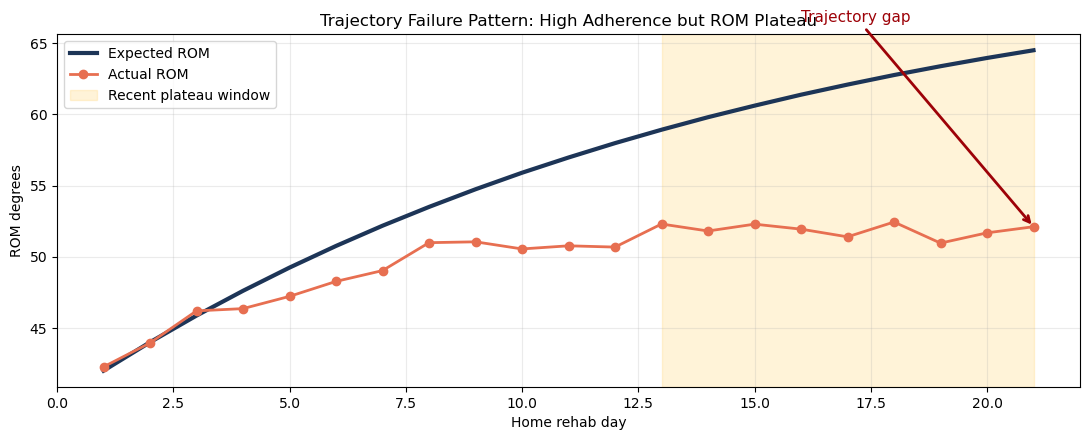

In [31]:
# %% [markdown]
# ## 15. Visual: Plateau Detection
#
# The demo event is:
#
# - `ROM 35% below week-3 milestone`
# - `9-day plateau`
# - no emergency threshold breach

# %%
def plot_plateau_detection(df):
    fig, ax = plt.subplots(figsize=(11, 4.5))

    ax.plot(
        df["home_rehab_day"],
        df["rom_degrees_expected"],
        label="Expected ROM",
        linewidth=3,
        color="#1D3557"
    )

    ax.plot(
        df["home_rehab_day"],
        df["rom_degrees_actual"],
        label="Actual ROM",
        marker="o",
        linewidth=2,
        color="#E76F51"
    )

    plateau_df = df.tail(9)

    ax.axvspan(
        plateau_df["home_rehab_day"].min(),
        plateau_df["home_rehab_day"].max(),
        color="#FFD166",
        alpha=0.25,
        label="Recent plateau window"
    )

    final_day = df["home_rehab_day"].iloc[-1]
    final_actual = df["rom_degrees_actual"].iloc[-1]
    final_expected = df["rom_degrees_expected"].iloc[-1]

    ax.annotate(
        "Trajectory gap",
        xy=(final_day, final_actual),
        xytext=(final_day - 5, final_expected + 2),
        arrowprops=dict(arrowstyle="->", color="#9D0208", linewidth=2),
        fontsize=11,
        color="#9D0208"
    )

    ax.set_title("Trajectory Failure Pattern: High Adherence but ROM Plateau")
    ax.set_xlabel("Home rehab day")
    ax.set_ylabel("ROM degrees")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_plateau_detection(daily_df)

In [33]:
# %% [markdown]
# ## 16. Logistic Alert Probability
#
# This is a transparent logistic-regression-style scoring function for demo purposes.
#
# It is not autonomous prescribing.
#
# Emergency thresholds stay outside ML.

# %%
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def logistic_alert_probability(
    rom_gap_percent,
    plateau_days,
    adherence,
    pain_score,
    complexity_score
):
    """
    Demo logistic-regression-style probability.

    Higher probability means greater likelihood that human review is needed.
    """

    z = -3.0

    z += 5.0 * rom_gap_percent
    z += 0.22 * plateau_days
    z += 1.2 * max(0, adherence - 0.8)
    z += 0.12 * max(0, pain_score - 3)
    z += 0.10 * complexity_score

    probability = sigmoid(z)

    return float(probability)

rom_gap_percent = abs(rom_analysis["gap_percent"])
plateau_days = rom_analysis["plateau_days"]
latest_adherence = float(daily_df["adherence_actual"].tail(7).mean())
latest_pain = float(daily_df["pain_score_actual"].tail(7).mean())
complexity_score = personalized_plan["complexity_score"]

alert_probability = logistic_alert_probability(
    rom_gap_percent=rom_gap_percent,
    plateau_days=plateau_days,
    adherence=latest_adherence,
    pain_score=latest_pain,
    complexity_score=complexity_score
)

print("Alert probability:", round(alert_probability, 3))

Alert probability: 0.285


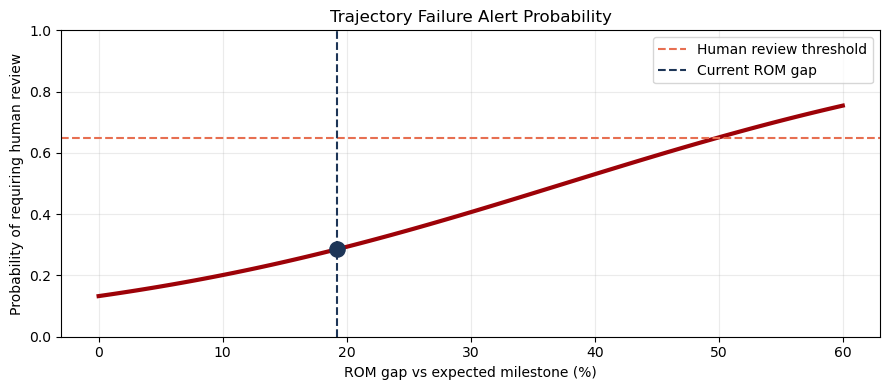

In [35]:
# %% [markdown]
# ## 17. Visual: Alert Probability Curve

# %%
def plot_alert_probability_curve(
    plateau_days,
    adherence,
    pain_score,
    complexity_score
):
    gap_values = np.linspace(0, 0.6, 100)

    probabilities = [
        logistic_alert_probability(
            rom_gap_percent=g,
            plateau_days=plateau_days,
            adherence=adherence,
            pain_score=pain_score,
            complexity_score=complexity_score
        )
        for g in gap_values
    ]

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(
        gap_values * 100,
        probabilities,
        color="#9D0208",
        linewidth=3
    )

    ax.axhline(
        0.65,
        color="#E76F51",
        linestyle="--",
        label="Human review threshold"
    )

    ax.axvline(
        rom_gap_percent * 100,
        color="#1D3557",
        linestyle="--",
        label="Current ROM gap"
    )

    ax.scatter(
        [rom_gap_percent * 100],
        [alert_probability],
        s=120,
        color="#1D3557",
        zorder=3
    )

    ax.set_title("Trajectory Failure Alert Probability")
    ax.set_xlabel("ROM gap vs expected milestone (%)")
    ax.set_ylabel("Probability of requiring human review")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_alert_probability_curve(
    plateau_days=plateau_days,
    adherence=latest_adherence,
    pain_score=latest_pain,
    complexity_score=complexity_score
)

In [37]:
# %% [markdown]
# ## 18. Decision Engine
#
# Output event:
#
# `TRAJECTORY_FAILURE_DETECTED`

# %%
def decision_engine(plan, daily_df, rehab_anchor):
    rom = analyze_metric_trajectory(daily_df, "rom_degrees")
    reps = analyze_metric_trajectory(daily_df, "exercise_reps")
    walking = analyze_metric_trajectory(daily_df, "walking_minutes")

    latest_adherence = float(daily_df["adherence_actual"].tail(7).mean())
    latest_pain = float(daily_df["pain_score_actual"].tail(7).mean())

    rom_gap_percent = abs(float(rom["gap_percent"]))
    plateau_days = int(rom["plateau_days"])

    probability = logistic_alert_probability(
        rom_gap_percent=rom_gap_percent,
        plateau_days=plateau_days,
        adherence=latest_adherence,
        pain_score=latest_pain,
        complexity_score=plan["complexity_score"]
    )

    rom_35_below = bool(rom_gap_percent >= 0.35)
    nine_day_plateau = bool(plateau_days >= 9)
    high_adherence = bool(latest_adherence >= 0.80)
    emergency_threshold_breach = False

    trajectory_failure = bool(
        rom_35_below
        and nine_day_plateau
        and high_adherence
        and not emergency_threshold_breach
    )

    decision = {
        "event_type": "TRAJECTORY_FAILURE_DETECTED" if trajectory_failure else "NO_TRAJECTORY_FAILURE",
        "requires_human_review": bool(trajectory_failure),
        "emergency_threshold_breach": bool(emergency_threshold_breach),
        "notification_path": "standard_non_emergency_escalation" if trajectory_failure else "continue_monitoring",
        "offline_first_status": {
            "local_analysis_completed": True,
            "queued_for_sync": bool(trajectory_failure),
            "connectivity_required_for_detection": False,
            "connectivity_required_for_escalation": True,
        },
        "primary_findings": {
            "rom_gap_percent": round(float(rom_gap_percent), 3),
            "rom_gap_human": "ROM 35% below week-3 milestone" if rom_35_below else "ROM gap below escalation threshold",
            "plateau_days": int(plateau_days),
            "plateau_human": "9-day plateau" if nine_day_plateau else f"{plateau_days}-day plateau",
            "average_recent_adherence": round(float(latest_adherence), 3),
            "average_recent_pain": round(float(latest_pain), 2),
            "alert_probability": round(float(probability), 3),
        },
        "metric_analyses": {
            "rom_degrees": rom,
            "exercise_reps": reps,
            "walking_minutes": walking,
        },
        "rehab_anchor": rehab_anchor,
        "access_dp_layers": {
            "L1": "L1 — CAREGIVER UI",
            "L2_L6": "L2 + L6 — OFFLINE QUEUE",
            "L3": "L3 — AGENTIC / MCP",
            "L4": "L4 — DECISION ENGINE",
            "L5": "L5 — RAG context",
            "L6": "L6 — OFFLINE SYNC",
        }
    }

    return decision

decision = decision_engine(personalized_plan, daily_df, rehab_anchor)

print(json.dumps(make_json_serializable(decision), indent=2))

{
  "event_type": "NO_TRAJECTORY_FAILURE",
  "requires_human_review": false,
  "emergency_threshold_breach": false,
  "notification_path": "continue_monitoring",
  "offline_first_status": {
    "local_analysis_completed": true,
    "queued_for_sync": false,
    "connectivity_required_for_detection": false,
    "connectivity_required_for_escalation": true
  },
  "primary_findings": {
    "rom_gap_percent": 0.192,
    "rom_gap_human": "ROM gap below escalation threshold",
    "plateau_days": 0,
    "plateau_human": "0-day plateau",
    "average_recent_adherence": 0.898,
    "average_recent_pain": 3.03,
    "alert_probability": 0.285
  },
  "metric_analyses": {
    "rom_degrees": {
      "metric": "rom_degrees",
      "final_actual": 52.11,
      "final_expected": 64.5,
      "gap": 12.39,
      "gap_percent": 0.192,
      "recent_9_day_slope": -0.055,
      "plateau_days": 0
    },
    "exercise_reps": {
      "metric": "exercise_reps",
      "final_actual": 17.67,
      "final_expected"

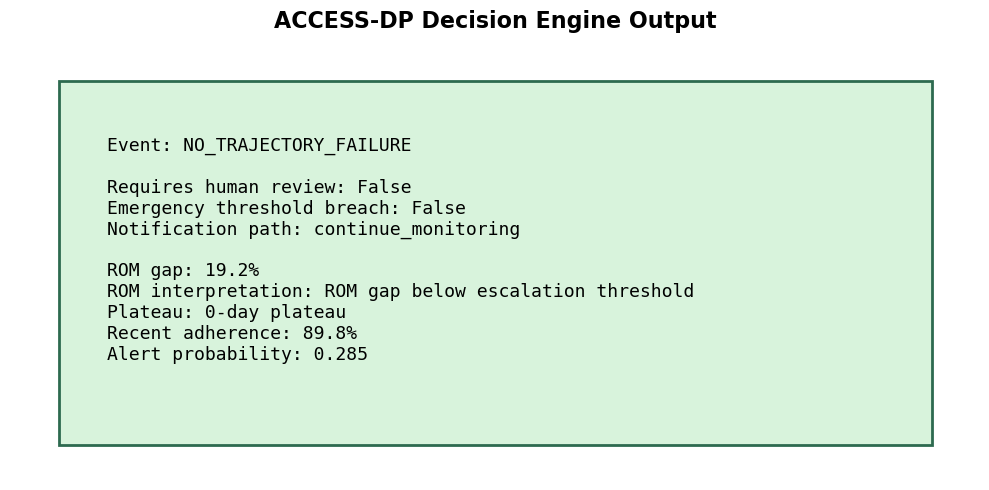

In [39]:
# %% [markdown]
# ## 19. Visual: Decision Summary Card

# %%
def draw_decision_card(decision):
    event_type = decision["event_type"]
    findings = decision["primary_findings"]

    color = "#FFE5D9" if event_type == "TRAJECTORY_FAILURE_DETECTED" else "#D8F3DC"
    edge = "#E76F51" if event_type == "TRAJECTORY_FAILURE_DETECTED" else "#2D6A4F"

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")

    rect = plt.Rectangle(
        (0.05, 0.08),
        0.90,
        0.82,
        facecolor=color,
        edgecolor=edge,
        linewidth=2
    )
    ax.add_patch(rect)

    text = f"""
    Event: {event_type}

    Requires human review: {decision['requires_human_review']}
    Emergency threshold breach: {decision['emergency_threshold_breach']}
    Notification path: {decision['notification_path']}

    ROM gap: {findings['rom_gap_percent'] * 100:.1f}%
    ROM interpretation: {findings['rom_gap_human']}
    Plateau: {findings['plateau_human']}
    Recent adherence: {findings['average_recent_adherence'] * 100:.1f}%
    Alert probability: {findings['alert_probability']:.3f}
    """

    ax.text(
        0.10,
        0.82,
        textwrap.dedent(text),
        fontsize=13,
        va="top",
        family="monospace"
    )

    ax.set_title("ACCESS-DP Decision Engine Output", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

draw_decision_card(decision)

In [41]:
# %% [markdown]
# ## 20. Caregiver Context Output
#
# This is written for Diane, the caregiver.
#
# It avoids blaming the caregiver or patient.
#
# It explains that adherence is good, but progress is behind the expected trajectory.

# %%
def caregiver_context(decision):
    if decision["event_type"] != "TRAJECTORY_FAILURE_DETECTED":
        return (
            "James's home rehabilitation logs are still being monitored. "
            "No trajectory failure was detected today."
        )

    findings = decision["primary_findings"]

    return f"""
ACCESS-DP caregiver update

James has been logging his rehabilitation activity consistently.

The app detected that his range-of-motion progress is not matching the expected recovery path.
This does not appear to be an emergency based on the information entered.

What the app noticed:
- His recent adherence remains high.
- His range of motion is about {findings['rom_gap_percent'] * 100:.1f}% below the week-3 milestone.
- His progress has been mostly flat for about {findings['plateau_days']} days.

Recommended next step:
A clinician should review James's progress and decide whether the rehab plan needs to be adjusted.

You do not need to call emergency services based on this alert alone unless James has new severe symptoms,
a fall with injury, chest pain, shortness of breath, sudden severe pain, or other urgent concerns.
""".strip()

caregiver_text = caregiver_context(decision)

print(caregiver_text)

James's home rehabilitation logs are still being monitored. No trajectory failure was detected today.


In [43]:
# %% [markdown]
# ## 21. Clinician Summary Output

# %%
def summarize_ehr_context(ehr_payload):
    context_items = []

    if payload_contains(ehr_payload, ["stroke", "cva", "hemiparesis", "hemiplegia"]):
        context_items.append("neurologic motor recovery context")

    if payload_contains(ehr_payload, ["spasticity", "spastic", "baclofen", "diazepam", "botox"]):
        context_items.append("tone/spasticity management context")

    if payload_contains(ehr_payload, ["contracture", "limited rom", "range of motion"]):
        context_items.append("ROM limitation or contracture context")

    if payload_contains(ehr_payload, ["hip dislocation", "subluxation", "dysplasia", "scoliosis"]):
        context_items.append("musculoskeletal structural limitation context")

    if payload_contains(ehr_payload, ["wheelchair", "afo", "stander"]):
        context_items.append("assistive device or mobility equipment context")

    if payload_contains(ehr_payload, ["pain", "chronic pain"]):
        context_items.append("pain-relevant rehabilitation context")

    if not context_items:
        context_items.append("no major EHR-derived rehab modifiers detected in extracted profile")

    return context_items

def clinician_summary(plan, decision, ehr_payload):
    findings = decision["primary_findings"]
    ehr_context = summarize_ehr_context(ehr_payload)

    text = f"""
ACCESS-DP clinician trajectory review note

Use case:
ACCESS-DP · USE CASE #3: LONG-TERM TRAJECTORY FAILURE

Patient:
James Okafor, 67 years old.
Post-stroke rehabilitation, monitored offline at home with caregiver assistance.

Event:
{decision['event_type']}

Summary:
The patient demonstrates high recent adherence to the home rehabilitation plan, but range-of-motion
progress is below the personalized expected trajectory.

Trajectory findings:
- ROM gap vs week-3 milestone: {findings['rom_gap_percent'] * 100:.1f}%
- Plateau duration: {findings['plateau_days']} days
- Recent adherence average: {findings['average_recent_adherence'] * 100:.1f}%
- Recent pain average: {findings['average_recent_pain']}
- Alert probability: {findings['alert_probability']}

Emergency status:
No emergency threshold breach was detected by the app.

EHR-derived rehab context used for personalization:
{chr(10).join("- " + item for item in ehr_context)}

Plan metadata:
- Plan ID: {plan['plan_id']}
- Condition group: {plan['condition_group']}
- Complexity score: {plan['complexity_score']} / 10
- Monitoring anchor: latest available EHR visit
- Relative day axis: {decision['rehab_anchor']['home_rehab_relative_axis']}

Requested review:
Please evaluate whether the home rehabilitation plan should be modified, whether additional assessment
is needed, or whether caregiver coaching is appropriate.
""".strip()

    return text

provider_note = clinician_summary(personalized_plan, decision, ehr_payload)

print(provider_note)

ACCESS-DP clinician trajectory review note

Use case:
ACCESS-DP · USE CASE #3: LONG-TERM TRAJECTORY FAILURE

Patient:
James Okafor, 67 years old.
Post-stroke rehabilitation, monitored offline at home with caregiver assistance.

Event:
NO_TRAJECTORY_FAILURE

Summary:
The patient demonstrates high recent adherence to the home rehabilitation plan, but range-of-motion
progress is below the personalized expected trajectory.

Trajectory findings:
- ROM gap vs week-3 milestone: 19.2%
- Plateau duration: 0 days
- Recent adherence average: 89.8%
- Recent pain average: 3.03
- Alert probability: 0.285

Emergency status:
No emergency threshold breach was detected by the app.

EHR-derived rehab context used for personalization:
- neurologic motor recovery context
- tone/spasticity management context
- ROM limitation or contracture context
- musculoskeletal structural limitation context
- assistive device or mobility equipment context
- pain-relevant rehabilitation context

Plan metadata:
- Plan ID:

In [46]:
# %% [markdown]
# ## 22. Secure Share Record Payload
#
# This creates the simulated payload that would be queued and synced when connectivity is available.
#
# Preserved ACCESS-DP references:
#
# - `share_record`
# - `JSON-RPC 2.0`
# - `FHIR R4`
# - `AES-GCM-256 ciphertext bundle`
# - `Signal Protocol / Double Ratchet Algorithm`
# - `SQLCipher`
# - `iOS Keychain / Android Keystore`

# %%
def create_share_record_payload(plan, decision, daily_df):
    payload = {
        "jsonrpc": "2.0",
        "method": "share_record",
        "params": {
            "event_type": decision["event_type"],
            "transport_profile": {
                "format": "FHIR R4",
                "envelope": "JSON-RPC 2.0",
                "encryption": "AES-GCM-256 ciphertext bundle",
                "session_security": "Signal Protocol / Double Ratchet Algorithm",
                "local_storage": "SQLCipher",
                "key_storage": "iOS Keychain / Android Keystore",
            },
            "offline_first": {
                "created_offline": True,
                "detection_requires_network": False,
                "queued_for_sync": decision["offline_first_status"]["queued_for_sync"],
                "sync_when_connectivity_returns": True,
            },
            "patient_summary": plan["patient"],
            "plan_id": plan["plan_id"],
            "decision": decision,
            "relative_timeline": {
                "rehab_anchor": decision["rehab_anchor"],
                "home_rehab_day_start": int(daily_df["home_rehab_day"].min()),
                "home_rehab_day_end": int(daily_df["home_rehab_day"].max()),
                "ehr_relative_day_start": int(daily_df["ehr_relative_day"].min()),
                "ehr_relative_day_end": int(daily_df["ehr_relative_day"].max()),
            },
            "attachments": {
                "personalized_plan_json": "personalized_plan.json",
                "synthetic_daily_rehab_data_csv": "synthetic_daily_rehab_data.csv",
                "trajectory_decision_payload_json": "trajectory_decision_payload.json",
                "caregiver_context_txt": "caregiver_context.txt",
                "provider_note_txt": "provider_note.txt",
            }
        },
        "id": "access-dp-share-record-demo-001"
    }

    return payload

share_record_payload = create_share_record_payload(
    personalized_plan,
    decision,
    daily_df
)

print(json.dumps(make_json_serializable(share_record_payload), indent=2)[:3000])

{
  "jsonrpc": "2.0",
  "method": "share_record",
  "params": {
    "event_type": "NO_TRAJECTORY_FAILURE",
    "transport_profile": {
      "format": "FHIR R4",
      "envelope": "JSON-RPC 2.0",
      "encryption": "AES-GCM-256 ciphertext bundle",
      "session_security": "Signal Protocol / Double Ratchet Algorithm",
      "local_storage": "SQLCipher",
      "key_storage": "iOS Keychain / Android Keystore"
    },
    "offline_first": {
      "created_offline": true,
      "detection_requires_network": false,
      "queued_for_sync": false,
      "sync_when_connectivity_returns": true
    },
    "patient_summary": {
      "name": "James Okafor",
      "age": "67 years old",
      "condition": "Post-stroke rehabilitation, monitored entirely offline at home",
      "caregiver": "Diane, wife, non-clinical",
      "location": "Rural Maryland, intermittent connectivity"
    },
    "plan_id": "ACCESS-DP-REHAB-PLAN-DEMO-001",
    "decision": {
      "event_type": "NO_TRAJECTORY_FAILURE",
    

In [48]:
# %% [markdown]
# ## 23. Save Outputs

# %%
save_json(personalized_plan, OUTPUT_DIR / "personalized_plan.json")
save_json(decision, OUTPUT_DIR / "trajectory_decision_payload.json")
save_json(share_record_payload, OUTPUT_DIR / "share_record_payload.json")

daily_df.to_csv(OUTPUT_DIR / "synthetic_daily_rehab_data.csv", index=False)
print(f"Saved CSV: {OUTPUT_DIR / 'synthetic_daily_rehab_data.csv'}")

if not ehr_timeline_df.empty:
    ehr_timeline_df.to_json(
        OUTPUT_DIR / "encounter_timeline.json",
        orient="records",
        indent=2
    )
    print(f"Saved JSON: {OUTPUT_DIR / 'encounter_timeline.json'}")

save_text(caregiver_text, OUTPUT_DIR / "caregiver_context.txt")
save_text(provider_note, OUTPUT_DIR / "provider_note.txt")

Saved JSON: access_dp_outputs\personalized_plan.json
Saved JSON: access_dp_outputs\trajectory_decision_payload.json
Saved JSON: access_dp_outputs\share_record_payload.json
Saved CSV: access_dp_outputs\synthetic_daily_rehab_data.csv
Saved JSON: access_dp_outputs\encounter_timeline.json
Saved text: access_dp_outputs\caregiver_context.txt
Saved text: access_dp_outputs\provider_note.txt
